<a href="https://colab.research.google.com/github/claugmdq-gif/EDA-Dataset-_Reporte-de-felicidad-mundial/blob/main/dataset_worldhapiness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

El coeficiente de correlación de Pearson es: 0.74


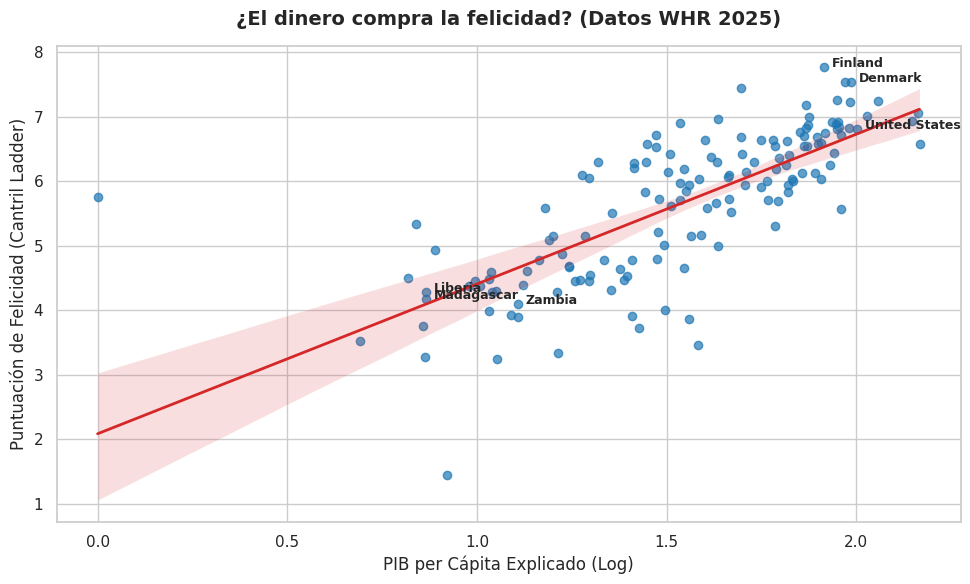

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Cargar el dataset
df = pd.read_csv("world_happiness_report_2005_2025.csv")

# 2. Filtrar para el año más reciente (2025) para tener una foto actual y limpia
df_2025 = df[df["year"] == 2025].dropna(
    subset=["happiness_score", "explained_log_gdp_per_capita"]
)

# 3. Calcular la correlación estadística
correlacion = df_2025["happiness_score"].corr(
    df_2025["explained_log_gdp_per_capita"]
)
print(f"El coeficiente de correlación de Pearson es: {correlacion:.2f}")

# 4. Configurar el estilo del gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 5. Crear el gráfico de dispersión con línea de regresión
sns.regplot(
    data=df_2025,
    x="explained_log_gdp_per_capita",
    y="happiness_score",
    scatter_kws={"alpha": 0.7, "color": "#1f77b4"},
    line_kws={"color": "#d62728", "linewidth": 2},
)

# Añadir etiquetas de texto para algunos países clave como referencia visual
paises_destacados = [
    "Finland",
    "Denmark",
    "United States",
    "Zambia",
    "Madagascar",
    "Liberia",
]
for idx, row in df_2025.iterrows():
    if row["country"] in paises_destacados:
        plt.text(
            row["explained_log_gdp_per_capita"] + 0.02,
            row["happiness_score"],
            row["country"],
            fontsize=9,
            weight="bold",
        )

# Personalizar el gráfico
plt.title(
    "¿El dinero compra la felicidad? (Datos WHR 2025)",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("PIB per Cápita Explicado (Log)", fontsize=12)
plt.ylabel("Puntuación de Felicidad (Cantril Ladder)", fontsize=12)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

Paso 1: Carga y Visualización "Pro"

In [2]:
import pandas as pd
df = pd.read_csv('/content/world_happiness_report_2005_2025.csv')

# Solo escribe el nombre de la variable o usa head() al final
df.head()


,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
0,2011,1,Denmark,7.856,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011,2,Finland,7.579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011,3,Norway,7.524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011,4,Netherlands,7.512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2011,5,Canada,7.499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Paso 2: Análisis de Datos Faltantes (Visual)

In [3]:
df.isnull().sum()

,0
year,0
rank_in_year,0
country,0
happiness_score,0
lower_whisker,1094
upper_whisker,1094
explained_log_gdp_per_capita,1097
explained_social_support,1097
explained_healthy_life_expectancy,1100
explained_freedom,1099


Paso 3: Estadísticas Descriptivas
Esto te dará una tabla resumen perfecta para analizar la media, el mínimo y el máximo de tus datos:


In [4]:
df.describe()

,year,rank_in_year,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
count,2116.000000,2116.000000,2116.000000,1022.000000,1022.000000,1019.000000,1019.000000,1016.000000,1017.000000,1019.000000,1018.000000,1013.000000
mean,2018.220227,76.190926,5.465655,5.436091,5.664733,1.265670,1.096746,0.553435,0.609465,0.147343,0.144911,1.736935
std,4.249844,43.845101,1.123870,1.140959,1.107424,0.463823,0.357642,0.229980,0.212070,0.084335,0.118803,0.657497
min,2011.000000,1.000000,1.364000,1.301000,1.427000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.295000
25%,2015.000000,38.000000,4.604750,4.619707,4.867750,0.944000,0.865000,0.389750,0.471000,0.088000,0.063156,1.305000
50%,2018.000000,76.000000,5.480000,5.592631,5.812000,1.304000,1.140119,0.560500,0.602000,0.134000,0.113000,1.765000
75%,2022.000000,114.000000,6.321250,6.290110,6.486500,1.636000,1.382000,0.712325,0.735000,0.195477,0.181330,2.178000
max,2025.000000,158.000000,7.856000,7.780000,7.904000,2.209000,1.840000,1.238000,1.147000,0.569814,0.587000,3.482000


Paso 4: El "Agrupador" (Insights rápidos)
Si quieres saber, por ejemplo, el precio promedio por categoría:


In [8]:
df.groupby('country')['happiness_score'].mean()

,happiness_score
country,
Afghanistan,2.838993
Albania,5.078550
Algeria,5.437150
Angola,4.209333
Argentina,6.286479
...,...
Venezuela,5.624657
Viet Nam,5.540464
Yemen,3.744108


Paso 5: Gráficos sin "ruido"
Para que no aparezca un texto extraño arriba del gráfico (como <Axes: title={'center':...}>), añade un punto y coma (;) al final de la última línea de Matplotlib.


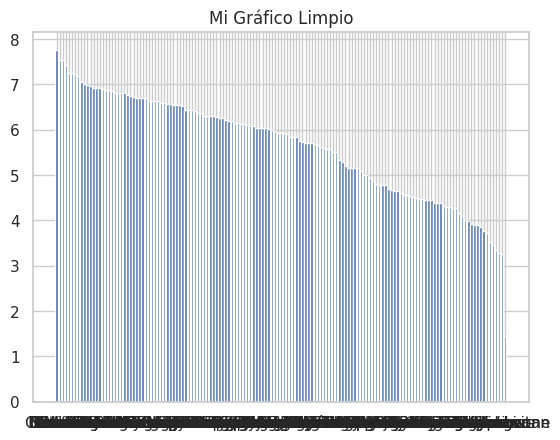

In [11]:
import matplotlib.pyplot as plt

plt.bar(df['country'], df['happiness_score'])
plt.title('Mi Gráfico Limpio')
plt.show(); # El punto y coma limpia la salida en Colab
